# Retail Sales & Customer Segmentation Analysis

**Goal:** Analyze 2 years of retail transaction data to uncover revenue trends, top-performing categories, and segment customers using RFM (Recency, Frequency, Monetary) analysis to support targeted retention strategies.

**Tools:** Python (pandas, matplotlib, seaborn), SQL

**Dataset:** Synthetic retail transactions (1,200 customers, 9,000 orders, Jan 2024 – Dec 2025) generated to mimic real e-commerce order patterns across 6 product categories and 12 Indian cities.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)


## 1. Load & Inspect Data

In [2]:
orders = pd.read_csv("../data/raw/orders.csv", parse_dates=["order_date"])
customers = pd.read_csv("../data/raw/customers.csv", parse_dates=["signup_date"])

print(orders.shape, customers.shape)
orders.head()


(9000, 13) (1200, 4)


,order_id,customer_id,order_date,category,product,unit_price,quantity,discount_pct,gross_amount,discount_amount,net_amount,payment_method,order_status
0,ORD002363,CUST00362,2024-01-09,Fashion,Running Shoes,1774.08,2,15,3548.16,532.22,3015.94,Net Banking,Delivered
1,ORD001876,CUST00362,2024-01-11,Beauty & Personal Care,Lip Balm,548.26,1,10,548.26,54.83,493.43,UPI,Delivered
2,ORD006607,CUST00532,2024-01-15,Home & Kitchen,Water Bottle,857.53,2,5,1715.06,85.75,1629.31,Debit Card,Delivered
3,ORD003700,CUST00256,2024-01-15,Home & Kitchen,Water Bottle,2475.81,2,0,4951.62,0.00,4951.62,Credit Card,Delivered
4,ORD001380,CUST00192,2024-01-17,Beauty & Personal Care,Hair Serum,1285.23,1,15,1285.23,192.78,1092.45,Debit Card,Delivered


In [3]:
orders.info()


<class 'pandas.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_id         9000 non-null   str           
 1   customer_id      9000 non-null   str           
 2   order_date       9000 non-null   datetime64[us]
 3   category         9000 non-null   str           
 4   product          9000 non-null   str           
 5   unit_price       9000 non-null   float64       
 6   quantity         9000 non-null   int64         
 7   discount_pct     9000 non-null   int64         
 8   gross_amount     9000 non-null   float64       
 9   discount_amount  9000 non-null   float64       
 10  net_amount       9000 non-null   float64       
 11  payment_method   9000 non-null   str           
 12  order_status     9000 non-null   str           
dtypes: datetime64[us](1), float64(4), int64(2), str(6)
memory usage: 914.2 KB


In [4]:
# Missing values & basic sanity checks
print("Missing values:\n", orders.isnull().sum())
print("\nOrder status distribution:\n", orders['order_status'].value_counts(normalize=True))


Missing values:
 order_id           0
customer_id        0
order_date         0
category           0
product            0
unit_price         0
quantity           0
discount_pct       0
gross_amount       0
discount_amount    0
net_amount         0
payment_method     0
order_status       0
dtype: int64

Order status distribution:
 order_status
Delivered    0.902000
Cancelled    0.059444
Returned     0.038556
Name: proportion, dtype: float64


## 2. Data Cleaning

We keep only `Delivered` orders for revenue-related analysis (cancelled/returned orders shouldn't count toward realized revenue), but keep the full dataset for operational metrics like cancellation rate.

In [5]:
delivered = orders[orders["order_status"] == "Delivered"].copy()
df = delivered.merge(customers, on="customer_id", how="left")
df["order_month"] = df["order_date"].dt.to_period("M").dt.to_timestamp()

print(f"Delivered orders: {len(df):,} / {len(orders):,} total ({len(df)/len(orders):.1%})")
df.head()


Delivered orders: 8,118 / 9,000 total (90.2%)


,order_id,customer_id,order_date,category,product,unit_price,quantity,discount_pct,gross_amount,discount_amount,net_amount,payment_method,order_status,city,city_tier,signup_date,order_month
0,ORD002363,CUST00362,2024-01-09,Fashion,Running Shoes,1774.08,2,15,3548.16,532.22,3015.94,Net Banking,Delivered,Mumbai,Tier 1,2024-01-04,2024-01-01
1,ORD001876,CUST00362,2024-01-11,Beauty & Personal Care,Lip Balm,548.26,1,10,548.26,54.83,493.43,UPI,Delivered,Mumbai,Tier 1,2024-01-04,2024-01-01
2,ORD006607,CUST00532,2024-01-15,Home & Kitchen,Water Bottle,857.53,2,5,1715.06,85.75,1629.31,Debit Card,Delivered,Nagpur,Tier 3,2024-01-13,2024-01-01
3,ORD003700,CUST00256,2024-01-15,Home & Kitchen,Water Bottle,2475.81,2,0,4951.62,0.00,4951.62,Credit Card,Delivered,Lucknow,Tier 2,2024-01-06,2024-01-01
4,ORD001380,CUST00192,2024-01-17,Beauty & Personal Care,Hair Serum,1285.23,1,15,1285.23,192.78,1092.45,Debit Card,Delivered,Jaipur,Tier 2,2024-01-02,2024-01-01


## 3. Exploratory Data Analysis

### 3.1 Monthly Revenue Trend

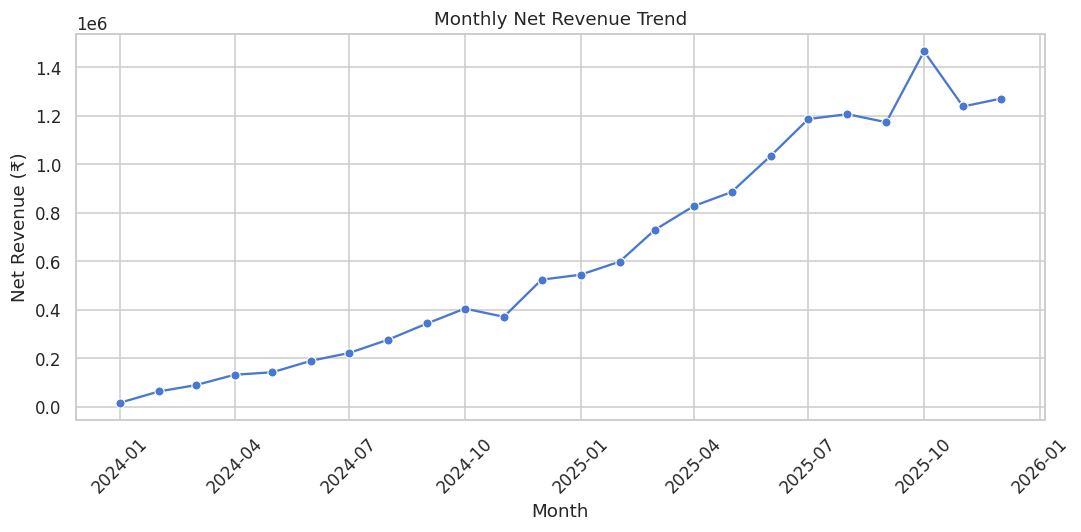

In [6]:
monthly_rev = df.groupby("order_month")["net_amount"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_rev, x="order_month", y="net_amount", marker="o")
plt.title("Monthly Net Revenue Trend")
plt.ylabel("Net Revenue (₹)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:** Revenue shows a generally upward trend with seasonal spikes — useful for forecasting and inventory planning.

### 3.2 Revenue by Category

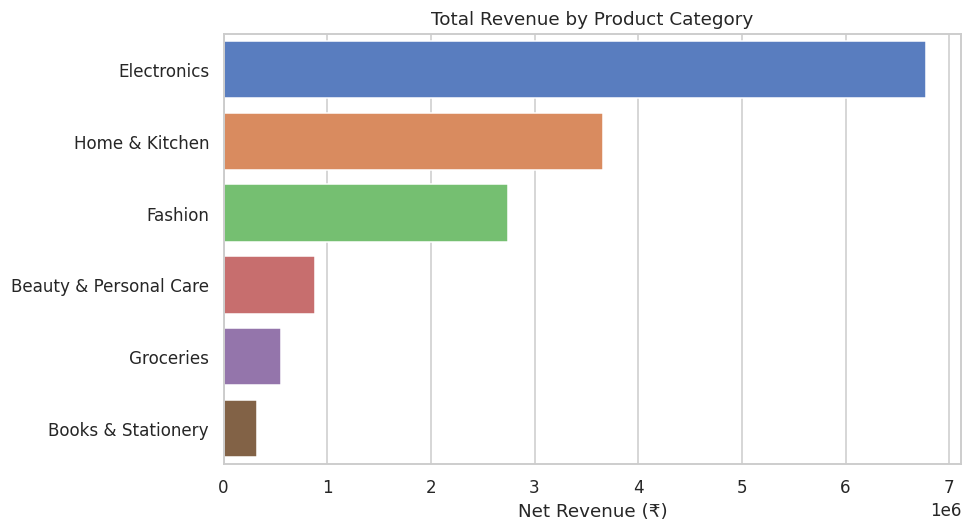

,category,net_amount
0,Electronics,6777908.22
1,Home & Kitchen,3656065.08
2,Fashion,2747241.03
3,Beauty & Personal Care,885515.65
4,Groceries,552165.01
5,Books & Stationery,321074.77


In [7]:
cat_rev = df.groupby("category")["net_amount"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(9, 5))
sns.barplot(data=cat_rev, x="net_amount", y="category", hue="category", legend=False)
plt.title("Total Revenue by Product Category")
plt.xlabel("Net Revenue (₹)")
plt.ylabel("")
plt.tight_layout()
plt.show()

cat_rev


### 3.3 Order Status Breakdown

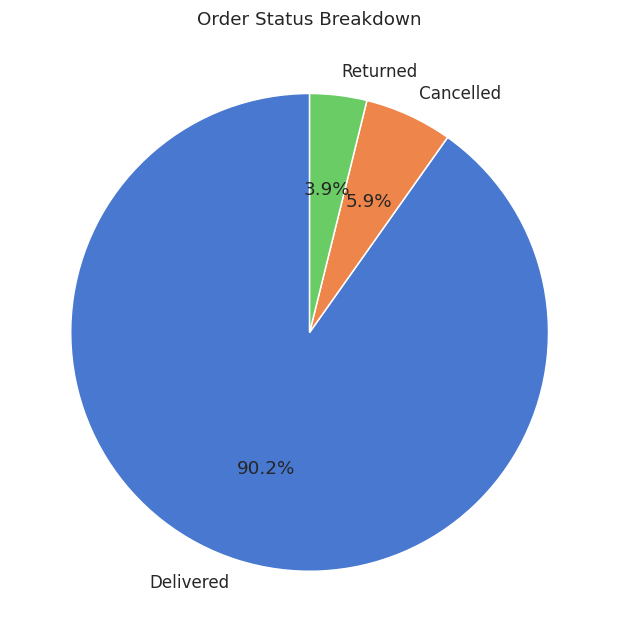

In [8]:
status_counts = orders["order_status"].value_counts(normalize=True).reset_index()
status_counts.columns = ["order_status", "pct"]

plt.figure(figsize=(6, 6))
plt.pie(status_counts["pct"], labels=status_counts["order_status"], autopct="%1.1f%%", startangle=90)
plt.title("Order Status Breakdown")
plt.tight_layout()
plt.show()


### 3.4 Revenue by City Tier

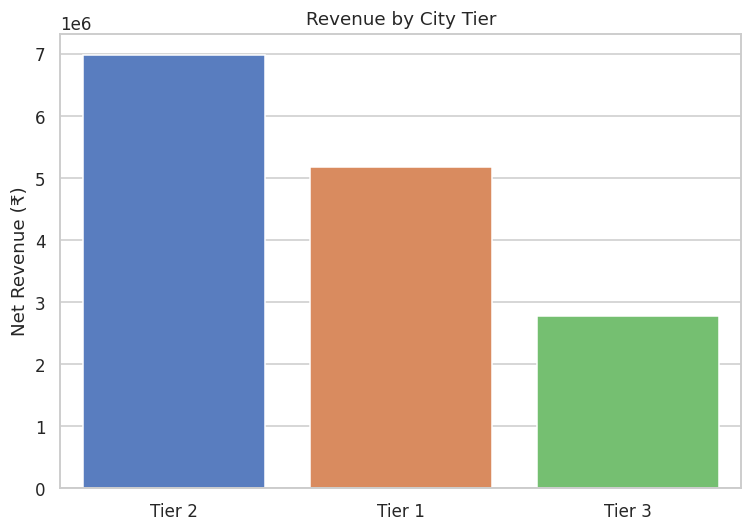

In [9]:
tier_rev = df.groupby("city_tier")["net_amount"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=tier_rev, x="city_tier", y="net_amount", hue="city_tier", legend=False)
plt.title("Revenue by City Tier")
plt.ylabel("Net Revenue (₹)")
plt.xlabel("")
plt.tight_layout()
plt.show()


**Insight:** Tier-1 cities drive the bulk of revenue, but Tier-2 cities represent a meaningful and potentially under-tapped growth segment.

## 4. RFM Customer Segmentation

We score each customer on **Recency** (days since last order), **Frequency** (number of orders), and **Monetary** value (total spend), then bucket them into actionable segments.

In [10]:
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("customer_id").agg(
    recency=("order_date", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("net_amount", "sum"),
).reset_index()

rfm["R_score"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

rfm.head()


,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,CUST00001,27,8,10746.71,4,4,3,11
1,CUST00002,44,3,6177.76,3,1,2,6
2,CUST00003,9,9,14455.12,5,4,4,13
3,CUST00004,21,8,13899.51,4,4,4,12
4,CUST00005,1,14,30171.46,5,5,5,15


In [11]:
def segment_customer(row):
    if row["RFM_score"] >= 13:
        return "Champions"
    elif row["RFM_score"] >= 10:
        return "Loyal Customers"
    elif row["RFM_score"] >= 7:
        return "Potential Loyalists"
    elif row["RFM_score"] >= 5:
        return "At Risk"
    else:
        return "Lost / Hibernating"

rfm["segment"] = rfm.apply(segment_customer, axis=1)

seg_summary = rfm.groupby("segment").agg(
    customers=("customer_id", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
).sort_values("avg_monetary", ascending=False)

seg_summary.round(1)


,customers,avg_recency,avg_frequency,avg_monetary
segment,,,,
Champions,233,16.0,14.9,28550.4
Loyal Customers,307,38.9,8.3,15771.6
Potential Loyalists,256,68.2,5.1,8571.3
At Risk,163,117.1,3.0,5034.8
Lost / Hibernating,170,243.3,1.7,2534.9


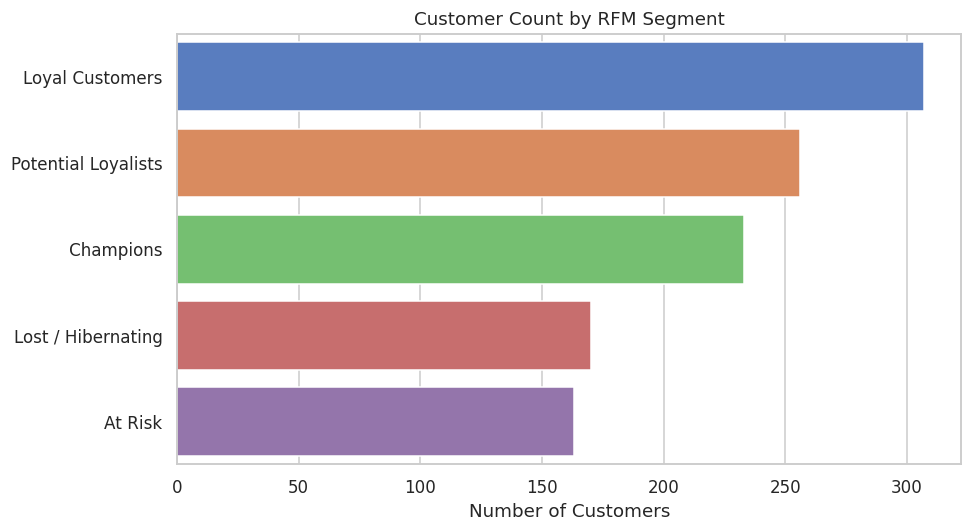

In [12]:
seg_counts = rfm["segment"].value_counts().reset_index()
seg_counts.columns = ["segment", "customers"]

plt.figure(figsize=(9, 5))
sns.barplot(data=seg_counts, x="customers", y="segment", hue="segment", legend=False,
            order=seg_counts.sort_values("customers", ascending=False)["segment"])
plt.title("Customer Count by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("")
plt.tight_layout()
plt.show()


**Business takeaway:**
- **Champions** (highest RFM) should get early access to new products and loyalty rewards — they are the most valuable, low-acquisition-cost segment.
- **At Risk** and **Lost/Hibernating** customers are candidates for win-back email campaigns or targeted discounts before they churn permanently.
- **Potential Loyalists** are a good audience for cross-sell campaigns to push them toward Loyal/Champion status.

## 5. Cohort Retention Analysis

We group customers by the month of their first purchase (cohort) and track what % of each cohort keeps ordering in subsequent months.

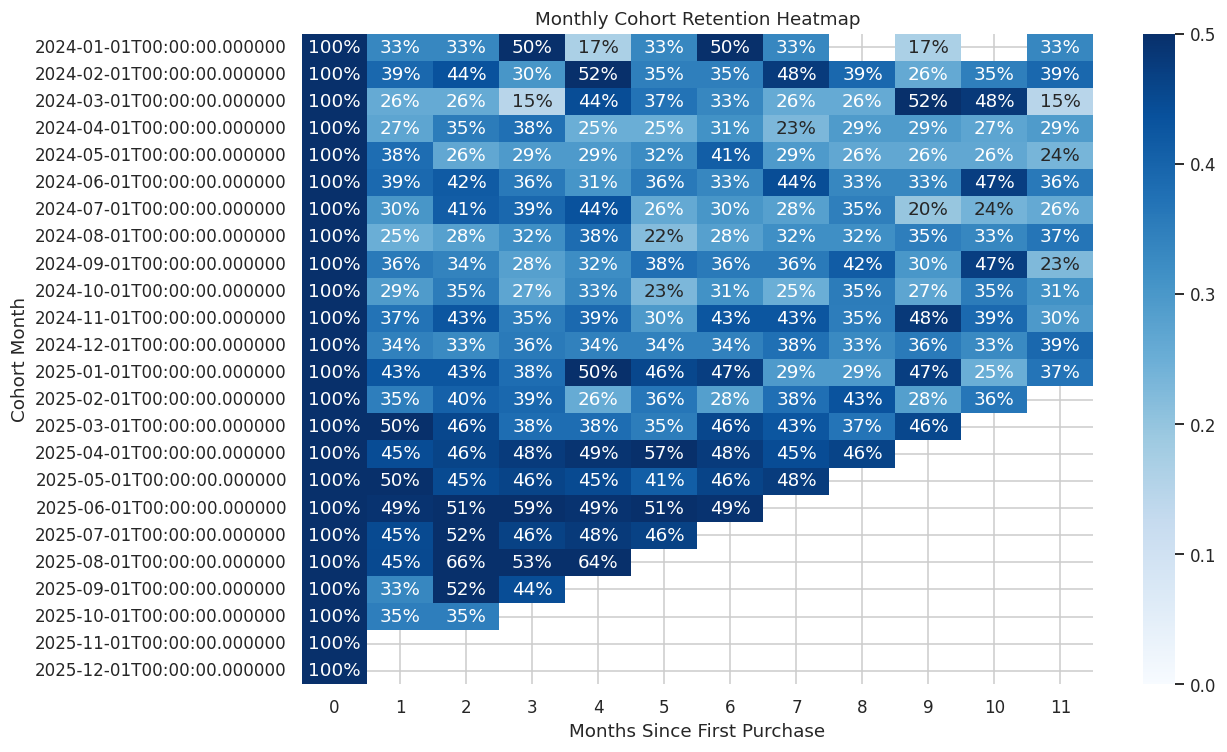

In [13]:
df["cohort_month"] = df.groupby("customer_id")["order_month"].transform("min")
df["cohort_index"] = (
    (df["order_month"].dt.year - df["cohort_month"].dt.year) * 12
    + (df["order_month"].dt.month - df["cohort_month"].dt.month)
)

cohort_data = df.groupby(["cohort_month", "cohort_index"])["customer_id"].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index="cohort_month", columns="cohort_index", values="customer_id")
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3)

plt.figure(figsize=(12, 7))
sns.heatmap(retention.iloc[:, :12], annot=True, fmt=".0%", cmap="Blues", vmin=0, vmax=0.5)
plt.title("Monthly Cohort Retention Heatmap")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()


**Insight:** Retention typically drops sharply after month 1, which is normal for retail — the key metric to watch is whether later cohorts retain *better* than earlier ones (a sign that retention initiatives are working).

## 6. Key Findings & Recommendations

1. **Revenue concentration:** Electronics and Home & Kitchen are the top two revenue-driving categories — prioritize inventory and marketing spend here.
2. **City tier opportunity:** Tier-2 cities contribute meaningfully to revenue despite lower individual order values — a localized marketing push could unlock further growth.
3. **Customer health:** ~20% of customers fall into "At Risk" or "Lost/Hibernating" segments. A win-back campaign (targeted discount + reminder email) could recover a portion of this revenue at low cost.
4. **Retention:** Month-1 retention is the biggest drop-off point — a structured onboarding flow (e.g. second-purchase discount) could improve early retention.
5. **Payment trends:** UPI dominates payment method share, reflecting broader Indian e-commerce trends — ensure UPI checkout experience remains frictionless.

---
*Full SQL versions of these analyses (CTEs + window functions) are available in `/sql/analysis_queries.sql`.*
